In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

c:\Users\UTD\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# ── Load cleaned data ───────────────────────────────────────────────────────
print("Loading data...")
df = pd.read_csv(
    r"C:\Users\UTD\OneDrive\Documents\supply-chain-analytics\data\cleaned\supply_chain_cleaned.csv",
    parse_dates=['order_date']
)

Loading data...


In [5]:
# ── Prepare monthly revenue data for Prophet ────────────────────────────────
monthly = (
    df.groupby(df['order_date'].dt.to_period('M'))['sales']
    .sum()
    .reset_index()
)
monthly['order_date'] = monthly['order_date'].dt.to_timestamp()
monthly.columns = ['ds', 'y']
print(f"Training on {len(monthly)} months of data")

Training on 37 months of data


In [6]:
# ── Train Prophet model ─────────────────────────────────────────────────────
print("Training forecasting model...")
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)
model.fit(monthly)

Training forecasting model...


21:29:14 - cmdstanpy - INFO - Chain [1] start processing
21:29:16 - cmdstanpy - INFO - Chain [1] done processing


In [7]:
# ── Forecast next 6 months ──────────────────────────────────────────────────
future = model.make_future_dataframe(periods=6, freq='MS')
forecast = model.predict(future)

 Forecast chart saved!


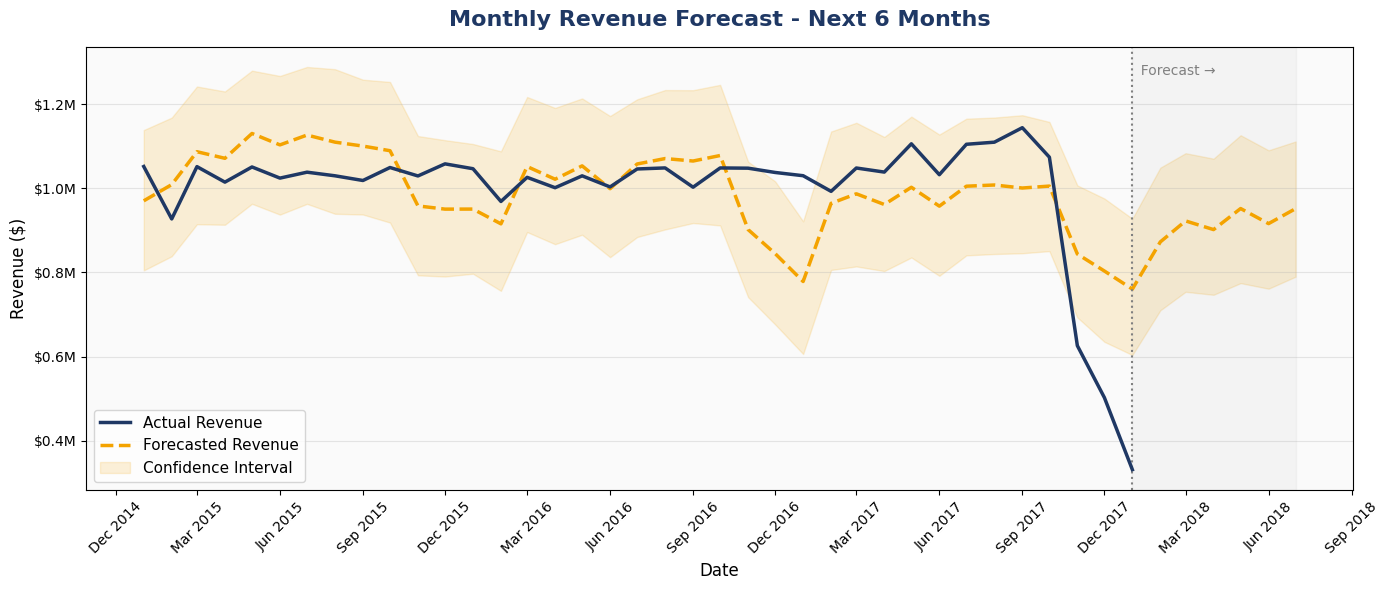

In [11]:
# ── Plot 1 — Forecast Chart ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(monthly['ds'], monthly['y'], 
        color='#1F3864', linewidth=2.5, label='Actual Revenue', zorder=3)
ax.plot(forecast['ds'], forecast['yhat'], 
        color='#F4A300', linewidth=2.5, linestyle='--', label='Forecasted Revenue')
ax.fill_between(forecast['ds'], 
                forecast['yhat_lower'], 
                forecast['yhat_upper'],
                alpha=0.15, color='#F4A300', label='Confidence Interval')

# Shade forecast period
last_actual = monthly['ds'].max()
ax.axvspan(last_actual, forecast['ds'].max(), alpha=0.05, color='grey')
ax.axvline(x=last_actual, color='grey', linestyle=':', linewidth=1.5)
ax.text(last_actual, ax.get_ylim()[1]*0.95, '  Forecast →', 
        color='grey', fontsize=10)

ax.set_title('Monthly Revenue Forecast - Next 6 Months', 
             fontsize=16, fontweight='bold', color='#1F3864', pad=15)
ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Revenue ($)', fontsize=12)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.savefig(
    r"C:\Users\UTD\OneDrive\Documents\supply-chain-analytics\screenshots\forecast_revenue.png",
    dpi=150, bbox_inches='tight'
)
print(" Forecast chart saved!")
plt.show()

 Seasonality chart saved!


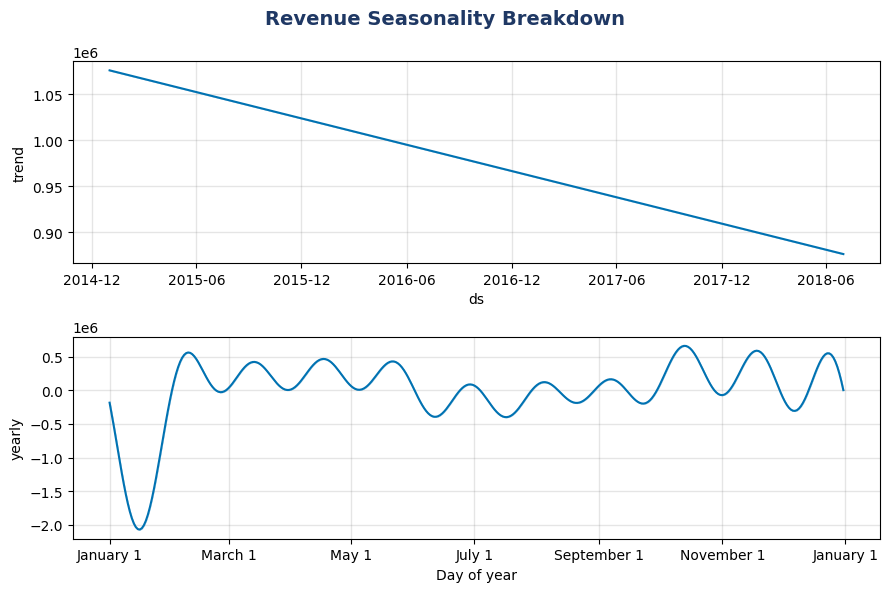

In [12]:
# ── Plot 2 — Seasonality Components ────────────────────────────────────────
fig2 = model.plot_components(forecast)
fig2.suptitle('Revenue Seasonality Breakdown', 
              fontsize=14, fontweight='bold', color='#1F3864')
plt.tight_layout()
plt.savefig(
    r"C:\Users\UTD\OneDrive\Documents\supply-chain-analytics\screenshots\forecast_seasonality.png",
    dpi=150, bbox_inches='tight'
)
print(" Seasonality chart saved!")
plt.show()

In [10]:
# ── Print forecast summary ──────────────────────────────────────────────────
print("\n 6-Month Revenue Forecast Summary:")
print("="*50)
future_only = forecast[forecast['ds'] > last_actual][['ds','yhat','yhat_lower','yhat_upper']]
future_only.columns = ['Month', 'Forecast', 'Lower Bound', 'Upper Bound']
future_only['Month'] = future_only['Month'].dt.strftime('%B %Y')
future_only[['Forecast','Lower Bound','Upper Bound']] = \
    future_only[['Forecast','Lower Bound','Upper Bound']].applymap(lambda x: f"${x:,.0f}")
print(future_only.to_string(index=False))


 6-Month Revenue Forecast Summary:
        Month Forecast Lower Bound Upper Bound
February 2018 $872,497    $709,974  $1,048,840
   March 2018 $922,291    $753,928  $1,083,190
   April 2018 $901,719    $746,782  $1,070,189
     May 2018 $951,723    $774,493  $1,125,835
    June 2018 $915,923    $761,300  $1,090,084
    July 2018 $951,508    $789,861  $1,111,009


In [14]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# ── Accuracy Evaluation ─────────────────────────────────────────────────────
# Compare actual vs predicted on training data
merged = monthly.merge(
    forecast[['ds', 'yhat']], on='ds', how='left'
)

mae  = mean_absolute_error(merged['y'], merged['yhat'])
mape = np.mean(np.abs((merged['y'] - merged['yhat']) / merged['y'])) * 100
rmse = np.sqrt(np.mean((merged['y'] - merged['yhat'])**2))

print("\n Model Accuracy Metrics:")
print("="*40)
print(f"MAE  (Mean Absolute Error):       ${mae:,.0f}")
print(f"MAPE (Mean Abs Percentage Error): {mape:.2f}%")
print(f"RMSE (Root Mean Square Error):    ${rmse:,.0f}")
print()



 Model Accuracy Metrics:
MAE  (Mean Absolute Error):       $95,296
MAPE (Mean Abs Percentage Error): 12.73%
RMSE (Root Mean Square Error):    $127,774

